In [18]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

os.makedirs("Figures", exist_ok=True)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"

ZIP_PATH = "UCI_HAR_Dataset.zip"
EXTRACT_PATH = "UCI_HAR_Dataset"

if not os.path.exists(EXTRACT_PATH):
    print("Downloading UCI HAR dataset...")

    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")

    print("Dataset extracted successfully.")
else:
    print("Dataset already exists.")

Extracting dataset...
Dataset extracted successfully.


In [3]:
ZIP_PATH = "UCI HAR Dataset.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(".")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

print("Number of channels:", len(SIGNALS))
print("Channels:")
for i, signal in enumerate(SIGNALS, start=1):
    print(i, signal)

Number of channels: 9
Channels:
1 body_acc_x
2 body_acc_y
3 body_acc_z
4 body_gyro_x
5 body_gyro_y
6 body_gyro_z
7 total_acc_x
8 total_acc_y
9 total_acc_z


In [5]:
def load_raw_signals(base_path, split):
    """
    Load the 9 raw inertial signals.

    Returns:
        X: numpy array of shape (N, 128, 9)
    """

    signal_path = os.path.join(
        base_path,
        split,
        "Inertial Signals"
    )

    signal_arrays = []

    for signal in SIGNALS:

        file_path = os.path.join(
            signal_path,
            f"{signal}_{split}.txt"
        )

        data = np.loadtxt(file_path)

        signal_arrays.append(data)

        print(
            f"{signal:15s} -> {data.shape}"
        )

    # Shape before transpose:
    # 9 × N × 128

    X = np.stack(signal_arrays, axis=-1)

    # Result:
    # N × 128 × 9

    return X

In [6]:
BASE_PATH = "UCI HAR Dataset"

X_train_full = load_raw_signals(
    BASE_PATH,
    "train"
)

X_test = load_raw_signals(
    BASE_PATH,
    "test"
)

print("\nFinal shapes:")
print("X_train:", X_train_full.shape)
print("X_test :", X_test.shape)

body_acc_x      -> (7352, 128)
body_acc_y      -> (7352, 128)
body_acc_z      -> (7352, 128)
body_gyro_x     -> (7352, 128)
body_gyro_y     -> (7352, 128)
body_gyro_z     -> (7352, 128)
total_acc_x     -> (7352, 128)
total_acc_y     -> (7352, 128)
total_acc_z     -> (7352, 128)
body_acc_x      -> (2947, 128)
body_acc_y      -> (2947, 128)
body_acc_z      -> (2947, 128)
body_gyro_x     -> (2947, 128)
body_gyro_y     -> (2947, 128)
body_gyro_z     -> (2947, 128)
total_acc_x     -> (2947, 128)
total_acc_y     -> (2947, 128)
total_acc_z     -> (2947, 128)

Final shapes:
X_train: (7352, 128, 9)
X_test : (2947, 128, 9)


In [7]:
ACTIVITY_NAMES = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

y_train_full = np.loadtxt(
    os.path.join(
        BASE_PATH,
        "train",
        "y_train.txt"
    ),
    dtype=int
)

y_test = np.loadtxt(
    os.path.join(
        BASE_PATH,
        "test",
        "y_test.txt"
    ),
    dtype=int
)

print("y_train shape:", y_train_full.shape)
print("y_test shape :", y_test.shape)

y_train shape: (7352,)
y_test shape : (2947,)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,   # gives approximately 70/15/15 overall
    random_state=42,
    stratify=y_train_full
)

print("Training shape  :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape   :", X_test.shape)

print("\nLabels:")
print("Training  :", y_train.shape)
print("Validation:", y_val.shape)
print("Testing   :", y_test.shape)

Training shape  : (6054, 128, 9)
Validation shape: (1298, 128, 9)
Testing shape   : (2947, 128, 9)

Labels:
Training  : (6054,)
Validation: (1298,)
Testing   : (2947,)


In [9]:
X_train_2d = X_train.reshape(-1, 9)

scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train_2d)


def normalize_sequences(X, scaler):
    original_shape = X.shape

    X_2d = X.reshape(-1, 9)

    X_scaled = scaler.transform(X_2d)

    return X_scaled.reshape(original_shape)


X_train = normalize_sequences(X_train, scaler)
X_val = normalize_sequences(X_val, scaler)
X_test = normalize_sequences(X_test, scaler)

print("Training mean:")
print(X_train.reshape(-1, 9).mean(axis=0))

print("\nTraining standard deviation:")
print(X_train.reshape(-1, 9).std(axis=0))

Training mean:
[-7.51758099e-17  1.66115927e-17  8.64692960e-17  5.36425501e-17
 -1.42976173e-16 -5.49542440e-18  7.76276439e-14  3.23822929e-16
 -3.84680547e-15]

Training standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
y_train = y_train - 1
y_val = y_val - 1
y_test = y_test - 1

print("Unique training labels:", np.unique(y_train))
print("Unique validation labels:", np.unique(y_val))
print("Unique test labels:", np.unique(y_test))

Unique training labels: [0 1 2 3 4 5]
Unique validation labels: [0 1 2 3 4 5]
Unique test labels: [0 1 2 3 4 5]


In [11]:
def show_class_distribution(y, name):
    counts = pd.Series(y).value_counts().sort_index()

    df = pd.DataFrame({
        "Activity": [
            ACTIVITY_NAMES[i + 1]
            for i in counts.index
        ],
        "Count": counts.values
    })

    print(f"\n{name}")
    display(df)


show_class_distribution(y_train, "Training Distribution")
show_class_distribution(y_val, "Validation Distribution")
show_class_distribution(y_test, "Testing Distribution")


Training Distribution


,Activity,Count
0,WALKING,1009
1,WALKING_UPSTAIRS,884
2,WALKING_DOWNSTAIRS,812
3,SITTING,1059
4,STANDING,1131
5,LAYING,1159



Validation Distribution


,Activity,Count
0,WALKING,217
1,WALKING_UPSTAIRS,189
2,WALKING_DOWNSTAIRS,174
3,SITTING,227
4,STANDING,243
5,LAYING,248



Testing Distribution


,Activity,Count
0,WALKING,496
1,WALKING_UPSTAIRS,471
2,WALKING_DOWNSTAIRS,420
3,SITTING,491
4,STANDING,532
5,LAYING,537


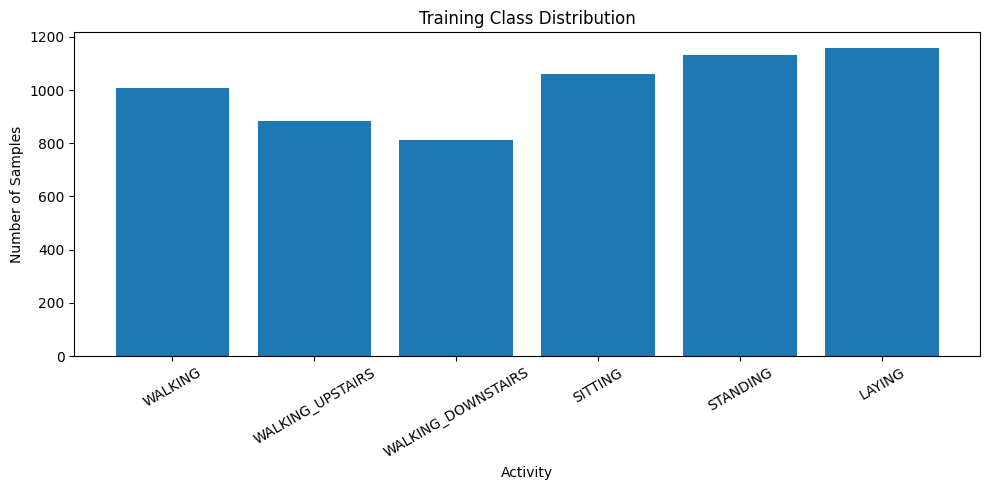

In [12]:
plt.figure(figsize=(10, 5))

counts = pd.Series(y_train).value_counts().sort_index()

plt.bar(
    [ACTIVITY_NAMES[i + 1] for i in counts.index],
    counts.values
)

plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.title("Training Class Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
print("=" * 50)
print("FINAL PREPROCESSING OUTPUT")
print("=" * 50)

print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")

print(f"\nNumber of classes           : {len(ACTIVITY_NAMES)}")
print(f"Number of features/time step: {X_train.shape[2]}")
print(f"Sequence length             : {X_train.shape[1]}")

FINAL PREPROCESSING OUTPUT
Training   : (6054, 128, 9)
Validation : (1298, 128, 9)
Testing    : (2947, 128, 9)

Number of classes           : 6
Number of features/time step: 9
Sequence length             : 128


In [14]:
selected_activities = [1, 2, 4]

selected_samples = {}

for activity in selected_activities:
    indices = np.where(y_train_full == activity)[0]

    # Take the first sample of this activity
    selected_samples[activity] = indices[0]

    print(
        ACTIVITY_NAMES[activity],
        "-> sample index:",
        indices[0]
    )

WALKING -> sample index: 78
WALKING_UPSTAIRS -> sample index: 150
SITTING -> sample index: 27


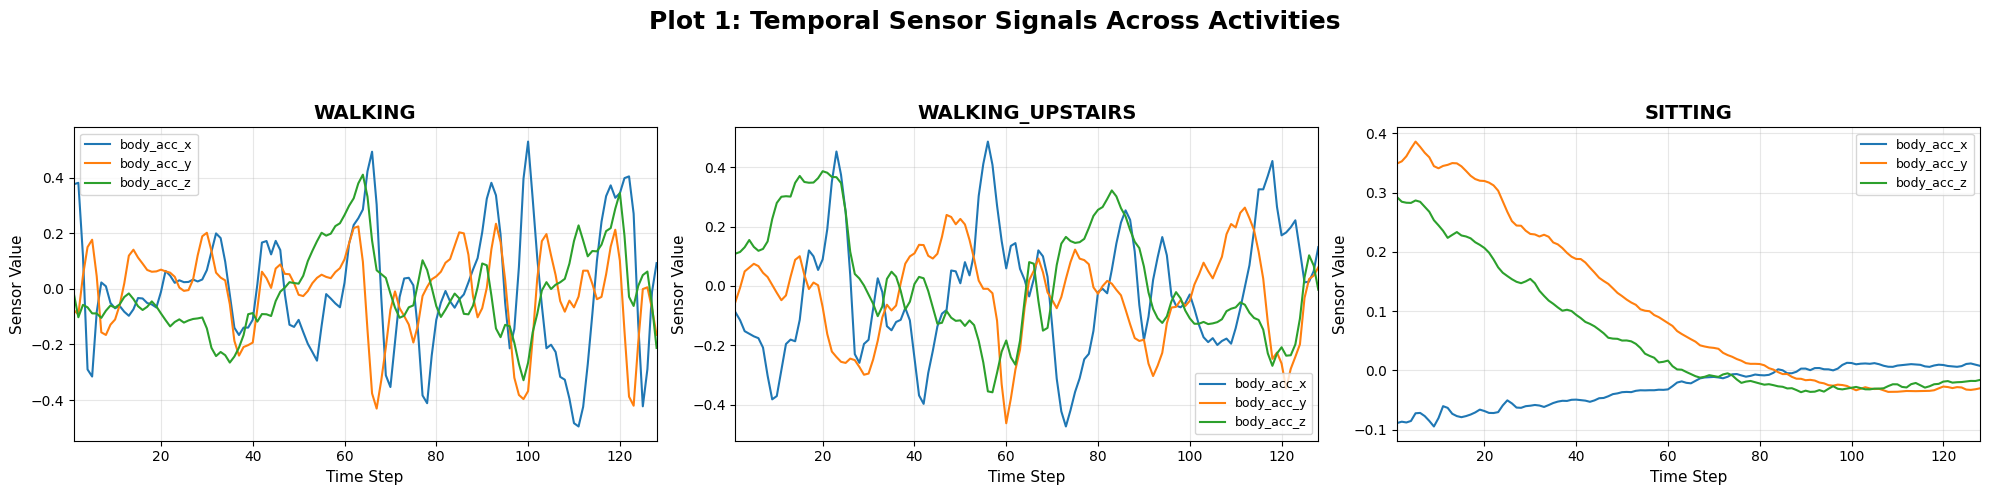

In [22]:
# Create Figures folder if it doesn't exist
import os
os.makedirs("Figures", exist_ok=True)

# Create 1 row × 3 columns
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 5)
)

# First 3 channels:
# 0 = Body Acceleration X
# 1 = Body Acceleration Y
# 2 = Body Acceleration Z
channels = [0, 1, 2]

for col, activity in enumerate(selected_activities):

    sample_index = selected_samples[activity]

    sequence = X_train_full[sample_index]

    # Plot X, Y, Z together
    for channel in channels:

        axes[col].plot(
            time_steps,
            sequence[:, channel],
            linewidth=1.5,
            label=SIGNALS[channel]
        )

    axes[col].set_title(
        ACTIVITY_NAMES[activity],
        fontsize=14,
        fontweight="bold"
    )

    axes[col].set_xlabel("Time Step", fontsize=11)
    axes[col].set_ylabel("Sensor Value", fontsize=11)

    axes[col].set_xlim(1, 128)

    axes[col].grid(
        alpha=0.3
    )

    axes[col].legend(
        fontsize=9
    )

# Overall title
fig.suptitle(
    "Plot 1: Temporal Sensor Signals Across Activities",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)

# Save ONE PNG at 600 DPI
save_path = "Figures/Plot_1_Temporal_Sensor_Signals.png"

plt.savefig(
    save_path,
    dpi=600,
    format="png",
    bbox_inches="tight"
)

plt.show()
plt.close()


In [27]:
import numpy as np

# Given values
x1 = 0.5
x2 = 0.7
x3 = 0.2

h0 = 0

Wx = 0.5
Wh = 0.8
b = 0.1

# Step 1
h1 = np.tanh(Wx * x1 + Wh * h0 + b)

# Step 2
h2 = np.tanh(Wx * x2 + Wh * h1 + b)

# Step 3
h3 = np.tanh(Wx * x3 + Wh * h2 + b)

print("Manual RNN calculation")
print("-" * 40)

print(f"h1 = {h1:.6f}")
print(f"h2 = {h2:.6f}")
print(f"h3 = {h3:.6f}")


x = [0.5, 0.7, 0.2]

h = 0.0

program_values = []

print("-" * 40)
print("Programming RNN calculation")
print("-" * 40)
for t, xt in enumerate(x, start=1):

    h = np.tanh(
        Wx * xt +
        Wh * h +
        b
    )

    program_values.append(h)

    print(f"h{t} = {h:.6f}")


manual_values = [h1, h2, h3]

print("\nComparison")
print("-" * 50)

for t, (manual, program) in enumerate(
    zip(manual_values, program_values),
    start=1
):
    print(
        f"h{t}: "
        f"Manual = {manual:.6f}, "
        f"Program = {program:.6f}, "
        f"Difference = {abs(manual-program):.10f}"
    )

Manual RNN calculation
----------------------------------------
h1 = 0.336376
h2 = 0.616352
h3 = 0.599958
----------------------------------------
Programming RNN calculation
----------------------------------------
h1 = 0.336376
h2 = 0.616352
h3 = 0.599958

Comparison
--------------------------------------------------
h1: Manual = 0.336376, Program = 0.336376, Difference = 0.0000000000
h2: Manual = 0.616352, Program = 0.616352, Difference = 0.0000000000
h3: Manual = 0.599958, Program = 0.599958, Difference = 0.0000000000


In [30]:
rnn_model = Sequential([

    Input(shape=(128, 9)),

    SimpleRNN(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(6, activation="softmax")
])

rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
learning_rate = 1e-3

rnn_model.compile(
    optimizer=Adam(
        learning_rate=learning_rate
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("RNN model compiled successfully.")

RNN model compiled successfully.


In [32]:
import time

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,
    batch_size=32,
    verbose=1
)

rnn_training_time = time.time() - start_time

print(
    f"\nRNN training time: "
    f"{rnn_training_time:.2f} seconds"
)

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4899 - loss: 1.2888 - val_accuracy: 0.5778 - val_loss: 1.0198
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6148 - loss: 0.9577 - val_accuracy: 0.5755 - val_loss: 1.0328
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5869 - loss: 0.9887 - val_accuracy: 0.6402 - val_loss: 0.8613
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6726 - loss: 0.7766 - val_accuracy: 0.7227 - val_loss: 0.6625
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6516 - loss: 0.8268 - val_accuracy: 0.6664 - val_loss: 0.8209
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6710 - loss: 0.7579 - val_accuracy: 0.6710 - val_loss: 0.7627
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6644 - loss: 0.7657 - val_accuracy: 0.7234 - val_loss: 0.6377
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7043 - loss: 0.6819 - val_accu

In [33]:
# Predict probabilities
rnn_probabilities = rnn_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

# Convert probabilities to predicted classes
rnn_predictions = np.argmax(
    rnn_probabilities,
    axis=1
)

# Metrics
rnn_accuracy = accuracy_score(
    y_test,
    rnn_predictions
)

rnn_precision = precision_score(
    y_test,
    rnn_predictions,
    average="macro"
)

rnn_recall = recall_score(
    y_test,
    rnn_predictions,
    average="macro"
)

rnn_f1 = f1_score(
    y_test,
    rnn_predictions,
    average="macro"
)

rnn_parameters = rnn_model.count_params()

print("=" * 50)
print("RNN TEST PERFORMANCE")
print("=" * 50)

print(f"Accuracy       : {rnn_accuracy * 100:.2f}%")
print(f"Macro Precision: {rnn_precision * 100:.2f}%")
print(f"Macro Recall   : {rnn_recall * 100:.2f}%")
print(f"Macro F1       : {rnn_f1 * 100:.2f}%")
print(f"Parameters     : {rnn_parameters:,}")
print(f"Training Time  : {rnn_training_time:.2f} seconds")

print("=" * 50)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
RNN TEST PERFORMANCE
Accuracy       : 74.31%
Macro Precision: 74.18%
Macro Recall   : 73.64%
Macro F1       : 73.79%
Parameters     : 1,974
Training Time  : 68.70 seconds


In [34]:
lstm_model = Sequential([

    Input(shape=(128, 9)),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(6, activation="softmax")
])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
lstm_model.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("LSTM model compiled successfully.")

LSTM model compiled successfully.


In [36]:
import time

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,
    batch_size=32,
    verbose=1
)

lstm_training_time = time.time() - start_time

print(
    f"\nLSTM training time: "
    f"{lstm_training_time:.2f} seconds"
)

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5456 - loss: 1.1655 - val_accuracy: 0.7311 - val_loss: 0.7099
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7821 - loss: 0.5385 - val_accuracy: 0.8752 - val_loss: 0.3452
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8964 - loss: 0.3056 - val_accuracy: 0.9322 - val_loss: 0.1978
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9205 - loss: 0.2409 - val_accuracy: 0.9553 - val_loss: 0.1406
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9460 - loss: 0.1520 - val_accuracy: 0.9307 - val_loss: 0.1808
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9387 - loss: 0.1726 - val_accuracy: 0.9461 - val_loss: 0.1409
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9381 - loss: 0.1656 - val_accuracy: 0.9492 - val_loss: 0.1409
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9453 - loss: 0.1426 - val_accurac

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predict probabilities
lstm_probabilities = lstm_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

# Convert probabilities to class predictions
lstm_predictions = np.argmax(
    lstm_probabilities,
    axis=1
)

# Calculate metrics
lstm_accuracy = accuracy_score(
    y_test,
    lstm_predictions
)

lstm_precision = precision_score(
    y_test,
    lstm_predictions,
    average="macro"
)

lstm_recall = recall_score(
    y_test,
    lstm_predictions,
    average="macro"
)

lstm_f1 = f1_score(
    y_test,
    lstm_predictions,
    average="macro"
)

lstm_parameters = lstm_model.count_params()

print("=" * 50)
print("LSTM TEST PERFORMANCE")
print("=" * 50)

print(f"Accuracy       : {lstm_accuracy * 100:.2f}%")
print(f"Macro Precision: {lstm_precision * 100:.2f}%")
print(f"Macro Recall   : {lstm_recall * 100:.2f}%")
print(f"Macro F1       : {lstm_f1 * 100:.2f}%")
print(f"Parameters     : {lstm_parameters:,}")
print(f"Training Time  : {lstm_training_time:.2f} seconds")

print("=" * 50)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
LSTM TEST PERFORMANCE
Accuracy       : 90.36%
Macro Precision: 90.51%
Macro Recall   : 90.61%
Macro F1       : 90.45%
Parameters     : 6,006
Training Time  : 77.67 seconds


In [38]:
# ------------------------------------------------------------
# 1. Build GRU model
# ------------------------------------------------------------

gru_model = Sequential([
    Input(shape=(128, 9)),
    GRU(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(6, activation="softmax")
])

gru_model.summary()

# ------------------------------------------------------------
# 2. Compile
# ------------------------------------------------------------

gru_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# 3. Train
# ------------------------------------------------------------

start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

gru_training_time = time.time() - start_time

print(f"\nGRU Training Time: {gru_training_time:.2f} seconds")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5003 - loss: 1.3262 - val_accuracy: 0.6710 - val_loss: 0.8150
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7585 - loss: 0.5980 - val_accuracy: 0.8390 - val_loss: 0.4015
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8500 - loss: 0.3693 - val_accuracy: 0.9191 - val_loss: 0.2725
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9166 - loss: 0.2496 - val_accuracy: 0.9384 - val_loss: 0.1666
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9465 - loss: 0.1589 - val_accuracy: 0.9576 - val_loss: 0.1262
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9495 - loss: 0.1360 - val_accuracy: 0.9615 - val_loss: 0.1154
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9529 - loss: 0.1269 - val_accuracy: 0.9569 - val_loss: 0.1084
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9488 - loss: 0.1283 - val_accuracy:

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred_prob = gru_model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)

gru_accuracy = accuracy_score(y_test, y_pred)

gru_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

gru_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

gru_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

gru_parameters = gru_model.count_params()

print("=" * 60)
print("GRU TEST RESULTS")
print("=" * 60)

print(f"Accuracy       : {gru_accuracy * 100:.2f}%")
print(f"Macro Precision: {gru_precision * 100:.2f}%")
print(f"Macro Recall   : {gru_recall * 100:.2f}%")
print(f"Macro F1-score : {gru_f1 * 100:.2f}%")
print(f"Parameters     : {gru_parameters:,}")
print(f"Training Time  : {gru_training_time:.2f} seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=list(ACTIVITY_NAMES.values()),
        digits=4,
        zero_division=0
    )
)

GRU TEST RESULTS
Accuracy       : 90.26%
Macro Precision: 90.41%
Macro Recall   : 90.42%
Macro F1-score : 90.36%
Parameters     : 4,758
Training Time  : 75.22 seconds

Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.9151    1.0000    0.9557       496
  WALKING_UPSTAIRS     0.9304    0.9087    0.9194       471
WALKING_DOWNSTAIRS     0.9500    0.9500    0.9500       420
           SITTING     0.7980    0.8045    0.8012       491
          STANDING     0.8308    0.8120    0.8213       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9026      2947
         macro avg     0.9041    0.9042    0.9036      2947
      weighted avg     0.9033    0.9026    0.9025      2947



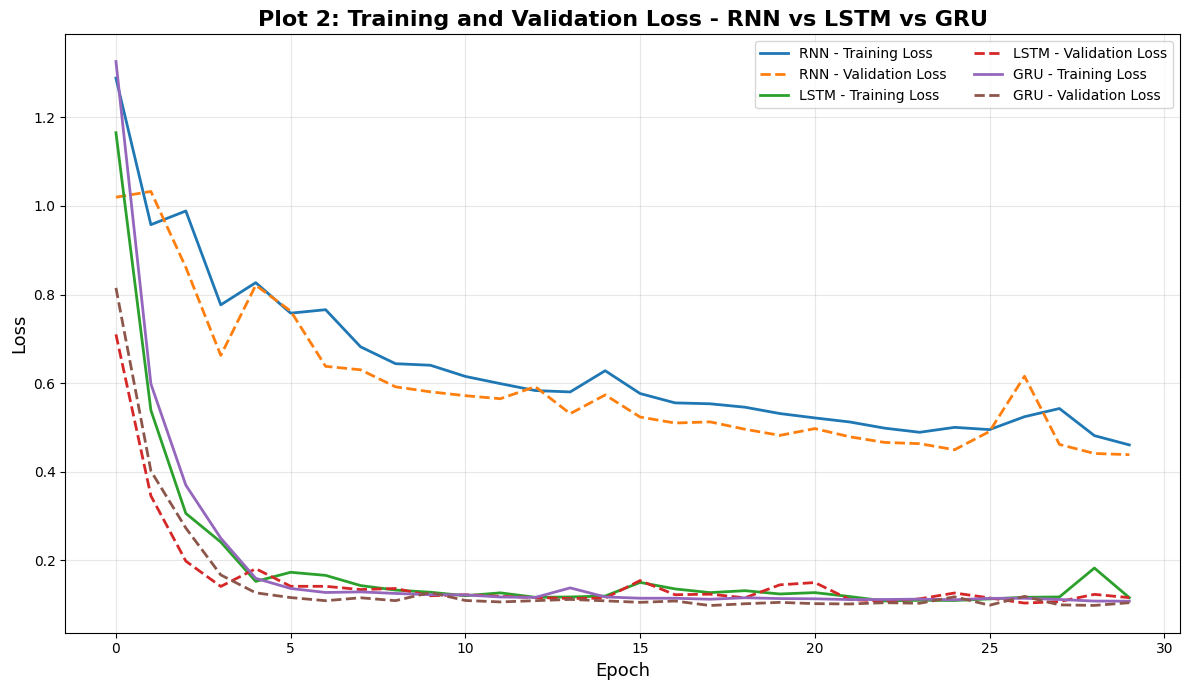

Saved successfully: Figures/Plot_2_Training_Validation_Loss_All_Models.png


In [40]:
plt.figure(figsize=(12, 7))

# -------------------------
# RNN
# -------------------------
plt.plot(
    rnn_history.history["loss"],
    label="RNN - Training Loss",
    linewidth=2
)

plt.plot(
    rnn_history.history["val_loss"],
    label="RNN - Validation Loss",
    linewidth=2,
    linestyle="--"
)

# -------------------------
# LSTM
# -------------------------
plt.plot(
    lstm_history.history["loss"],
    label="LSTM - Training Loss",
    linewidth=2
)

plt.plot(
    lstm_history.history["val_loss"],
    label="LSTM - Validation Loss",
    linewidth=2,
    linestyle="--"
)

# -------------------------
# GRU
# -------------------------
plt.plot(
    gru_history.history["loss"],
    label="GRU - Training Loss",
    linewidth=2
)

plt.plot(
    gru_history.history["val_loss"],
    label="GRU - Validation Loss",
    linewidth=2,
    linestyle="--"
)


plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)

plt.title(
    "Plot 2: Training and Validation Loss - RNN vs LSTM vs GRU",
    fontsize=16,
    fontweight="bold"
)

plt.legend(
    fontsize=10,
    ncol=2
)

plt.grid(alpha=0.3)

plt.tight_layout()

save_path = "Figures/Plot_2_Training_Validation_Loss_All_Models.png"

plt.savefig(
    save_path,
    dpi=600,
    format="png",
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Saved successfully: {save_path}")

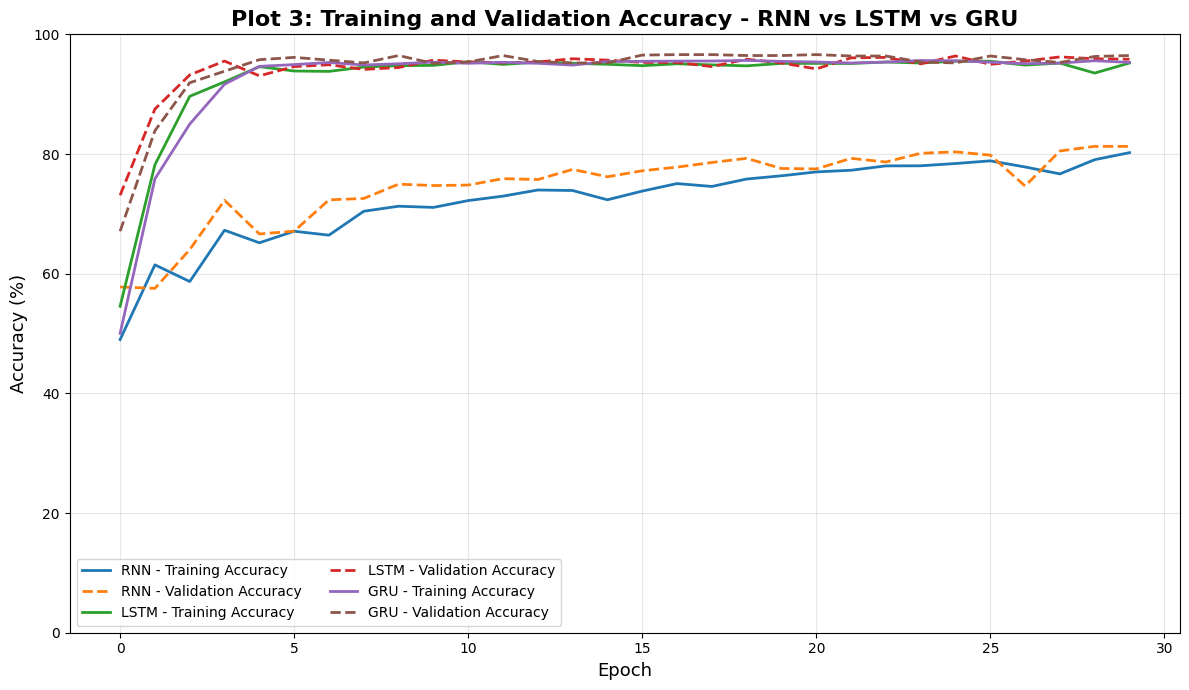

Saved successfully: Figures/Plot_3_Training_Validation_Accuracy_All_Models.png


In [41]:
plt.figure(figsize=(12, 7))

# -------------------------
# RNN
# -------------------------
plt.plot(
    np.array(rnn_history.history["accuracy"]) * 100,
    label="RNN - Training Accuracy",
    linewidth=2
)

plt.plot(
    np.array(rnn_history.history["val_accuracy"]) * 100,
    label="RNN - Validation Accuracy",
    linewidth=2,
    linestyle="--"
)

# -------------------------
# LSTM
# -------------------------
plt.plot(
    np.array(lstm_history.history["accuracy"]) * 100,
    label="LSTM - Training Accuracy",
    linewidth=2
)

plt.plot(
    np.array(lstm_history.history["val_accuracy"]) * 100,
    label="LSTM - Validation Accuracy",
    linewidth=2,
    linestyle="--"
)

# -------------------------
# GRU
# -------------------------
plt.plot(
    np.array(gru_history.history["accuracy"]) * 100,
    label="GRU - Training Accuracy",
    linewidth=2
)

plt.plot(
    np.array(gru_history.history["val_accuracy"]) * 100,
    label="GRU - Validation Accuracy",
    linewidth=2,
    linestyle="--"
)

# -------------------------
# Formatting
# -------------------------

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)

plt.title(
    "Plot 3: Training and Validation Accuracy - RNN vs LSTM vs GRU",
    fontsize=16,
    fontweight="bold"
)

plt.legend(
    fontsize=10,
    ncol=2
)

plt.grid(alpha=0.3)

plt.ylim(0, 100)

plt.tight_layout()

save_path = "Figures/Plot_3_Training_Validation_Accuracy_All_Models.png"

plt.savefig(
    save_path,
    dpi=600,
    format="png",
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Saved successfully: {save_path}")

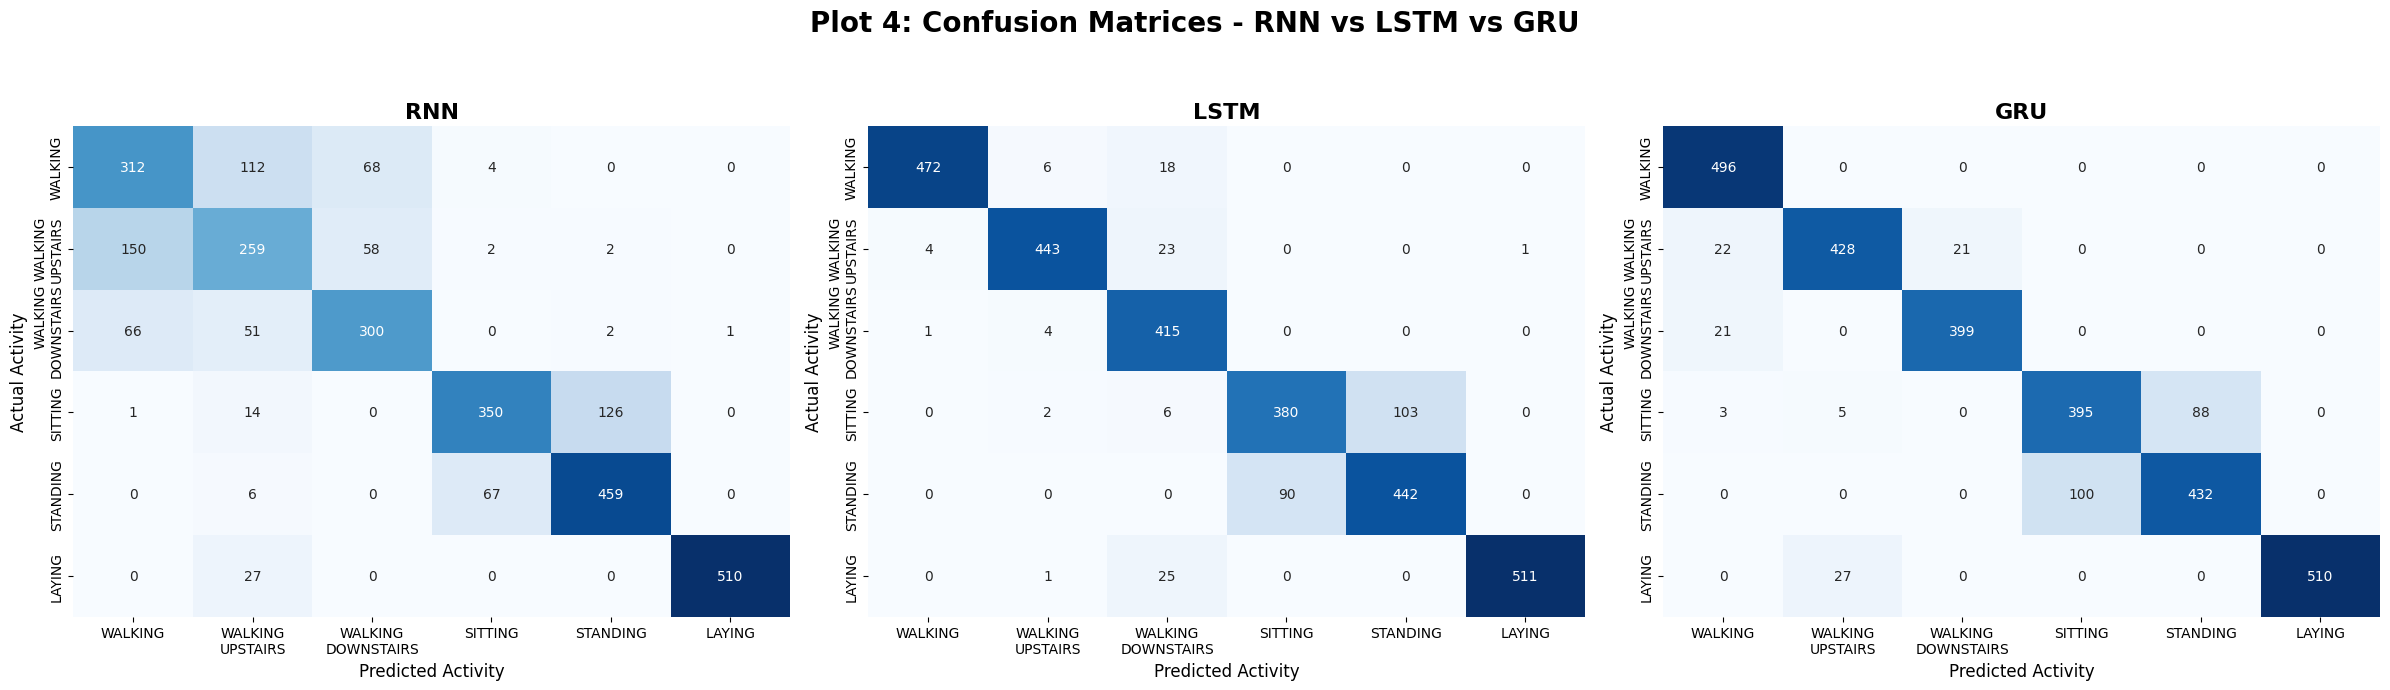

Saved successfully: Figures/Plot_4_Confusion_Matrices_All_Models.png


In [43]:
# ------------------------------------------------------------
# 1. Create confusion matrices using YOUR variable names
# ------------------------------------------------------------

cm_rnn = confusion_matrix(
    y_test,
    rnn_predictions
)

cm_lstm = confusion_matrix(
    y_test,
    lstm_predictions
)

cm_gru = confusion_matrix(
    y_test,
    y_pred
)

# ------------------------------------------------------------
# 2. Activity names
# ------------------------------------------------------------

class_names = [
    "WALKING",
    "WALKING\nUPSTAIRS",
    "WALKING\nDOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# ------------------------------------------------------------
# 3. Create ONE figure containing all 3 matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 7)
)

# ============================================================
# RNN
# ============================================================

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    cbar=False
)

axes[0].set_title(
    "RNN",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Predicted Activity",
    fontsize=12
)

axes[0].set_ylabel(
    "Actual Activity",
    fontsize=12
)

# ============================================================
# LSTM
# ============================================================

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    cbar=False
)

axes[1].set_title(
    "LSTM",
    fontsize=16,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Predicted Activity",
    fontsize=12
)

axes[1].set_ylabel(
    "Actual Activity",
    fontsize=12
)

# ============================================================
# GRU
# ============================================================

sns.heatmap(
    cm_gru,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[2],
    cbar=False
)

axes[2].set_title(
    "GRU",
    fontsize=16,
    fontweight="bold"
)

axes[2].set_xlabel(
    "Predicted Activity",
    fontsize=12
)

axes[2].set_ylabel(
    "Actual Activity",
    fontsize=12
)

# ============================================================
# Overall title
# ============================================================

fig.suptitle(
    "Plot 4: Confusion Matrices - RNN vs LSTM vs GRU",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

# ============================================================
# Save at 600 DPI
# ============================================================

save_path = "Figures/Plot_4_Confusion_Matrices_All_Models.png"

plt.savefig(
    save_path,
    dpi=600,
    format="png",
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Saved successfully: {save_path}")

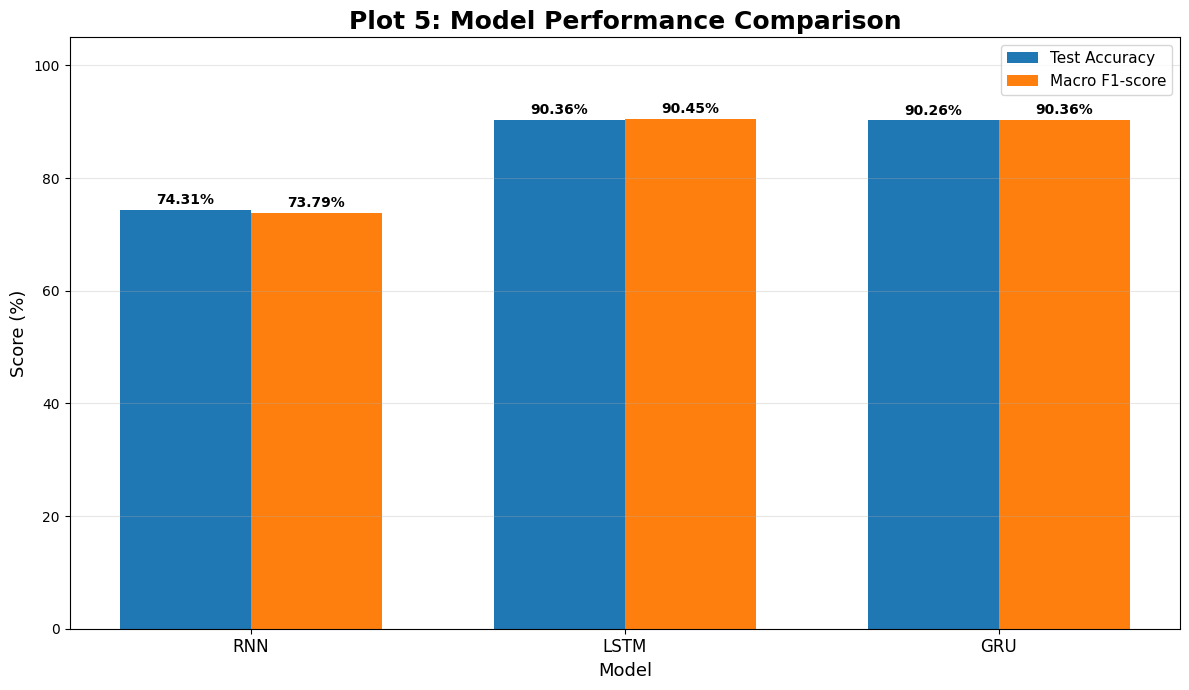

Saved successfully: Figures/Plot_5_Model_Performance_Comparison.png


In [44]:
models = ["RNN", "LSTM", "GRU"]

# ------------------------------------------------------------
# Test Accuracy (%)
# ------------------------------------------------------------

accuracy_values = [
    rnn_accuracy * 100,
    lstm_accuracy * 100,
    gru_accuracy * 100
]

# ------------------------------------------------------------
# Macro F1-score (%)
# ------------------------------------------------------------

f1_values = [
    rnn_f1 * 100,
    lstm_f1 * 100,
    gru_f1 * 100
]

# ------------------------------------------------------------
# Bar positions
# ------------------------------------------------------------

x = np.arange(len(models))

width = 0.35

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(
    x - width/2,
    accuracy_values,
    width,
    label="Test Accuracy"
)

bars2 = ax.bar(
    x + width/2,
    f1_values,
    width,
    label="Macro F1-score"
)

# ------------------------------------------------------------
# Add values on top of bars
# ------------------------------------------------------------

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            f"{height:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xlabel(
    "Model",
    fontsize=13
)

ax.set_ylabel(
    "Score (%)",
    fontsize=13
)

ax.set_title(
    "Plot 5: Model Performance Comparison",
    fontsize=18,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)

ax.set_ylim(
    0,
    105
)

ax.legend(
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# Save at 600 DPI
# ------------------------------------------------------------

save_path = "Figures/Plot_5_Model_Performance_Comparison.png"

plt.savefig(
    save_path,
    dpi=600,
    format="png",
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Saved successfully: {save_path}")

In [45]:
# ============================================================
# RNN vs LSTM vs GRU RESULTS TABLE
# ============================================================

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],

    "Accuracy (%)": [
        rnn_accuracy * 100,
        lstm_accuracy * 100,
        gru_accuracy * 100
    ],

    "Macro Precision (%)": [
        rnn_precision * 100,
        lstm_precision * 100,
        gru_precision * 100
    ],

    "Macro Recall (%)": [
        rnn_recall * 100,
        lstm_recall * 100,
        gru_recall * 100
    ],

    "Macro F1 (%)": [
        rnn_f1 * 100,
        lstm_f1 * 100,
        gru_f1 * 100
    ],

    "Parameters": [
        rnn_parameters,
        lstm_parameters,
        gru_parameters
    ],

    "Training Time (s)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

comparison_df

,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,74.312861,74.183489,73.642423,73.785377,1974,68.696826
1,LSTM,90.363081,90.512197,90.610014,90.449565,6006,77.671527
2,GRU,90.261283,90.405216,90.415605,90.364122,4758,75.215070


In [46]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Property": [
        "Hidden state",
        "Cell state",
        "Forget gate",
        "Input gate",
        "Output gate",
        "Update gate",
        "Reset gate",
        "Parameters",
        "Training time (s)",
        "Test F1-score (%)"
    ],
    "RNN": [
        "Yes", "No", "No", "No", "No", "No", "No",
        f"{rnn_parameters:,}",
        f"{rnn_training_time:.2f}",
        f"{rnn_f1 * 100:.2f}"
    ],
    "LSTM": [
        "Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
        f"{lstm_parameters:,}",
        f"{lstm_training_time:.2f}",
        f"{lstm_f1 * 100:.2f}"
    ],
    "GRU": [
        "Yes", "No", "No", "No", "No", "Yes", "Yes",
        f"{gru_parameters:,}",
        f"{gru_training_time:.2f}",
        f"{gru_f1 * 100:.2f}"
    ]
})

comparison_table

,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,"1,974","6,006","4,758"
8,Training time (s),68.70,77.67,75.22
9,Test F1-score (%),73.79,90.45,90.36


In [47]:
sequence_lengths = [32, 64, 128]

results = []

for length in sequence_lengths:

    X_test_seq = X_test[:, :length, :]

    rnn_pred = np.argmax(rnn_model.predict(X_test_seq, verbose=0), axis=1)
    lstm_pred = np.argmax(lstm_model.predict(X_test_seq, verbose=0), axis=1)
    gru_pred = np.argmax(gru_model.predict(X_test_seq, verbose=0), axis=1)

    rnn_f1_seq = f1_score(y_test, rnn_pred, average="macro")
    lstm_f1_seq = f1_score(y_test, lstm_pred, average="macro")
    gru_f1_seq = f1_score(y_test, gru_pred, average="macro")

    results.append([
        length,
        rnn_f1_seq * 100,
        lstm_f1_seq * 100,
        gru_f1_seq * 100
    ])

sequence_df = pd.DataFrame(
    results,
    columns=["Sequence Length", "RNN F1", "LSTM F1", "GRU F1"]
)

sequence_df

,Sequence Length,RNN F1,LSTM F1,GRU F1
0,32,73.263847,81.567463,85.577323
1,64,73.568286,88.364447,89.303951
2,128,73.785377,90.449565,90.364122


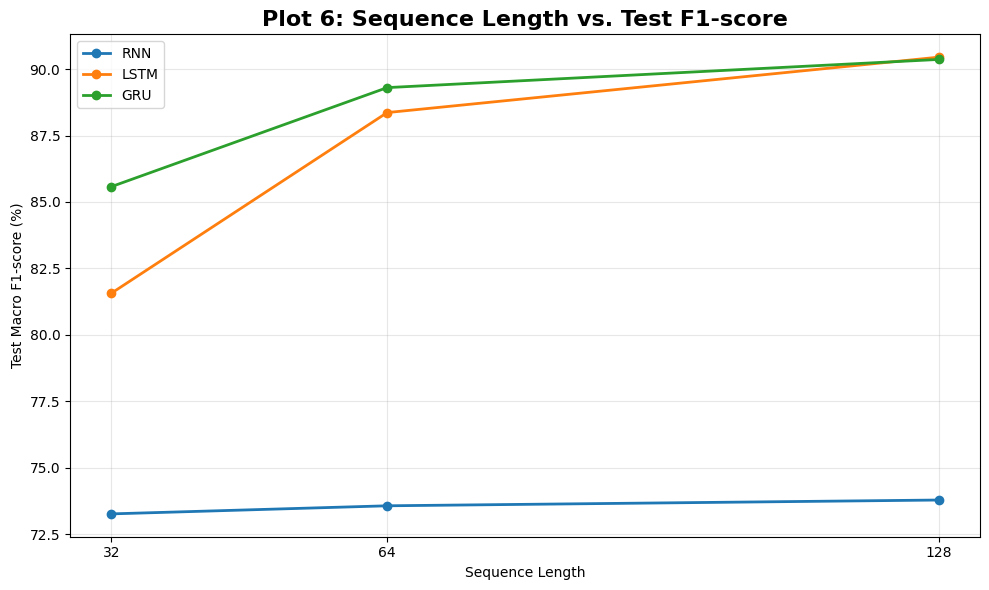

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["RNN F1"],
    marker="o",
    linewidth=2,
    label="RNN"
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["LSTM F1"],
    marker="o",
    linewidth=2,
    label="LSTM"
)

plt.plot(
    sequence_df["Sequence Length"],
    sequence_df["GRU F1"],
    marker="o",
    linewidth=2,
    label="GRU"
)

plt.xlabel("Sequence Length")
plt.ylabel("Test Macro F1-score (%)")

plt.title(
    "Plot 6: Sequence Length vs. Test F1-score",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(sequence_lengths)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figures/Plot_6_Sequence_Length_vs_F1.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [60]:
!wget --no-check-certificate -O /content/UCF101.rar \
"https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"

--2026-09-23 12:48:02--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 6932971618 (6.5G) [application/x-rar-compressed]
Saving to: ‘/content/UCF101.rar’

/content/UCF101.rar 100%[===================>]   6.46G  36.7MB/s    in 2m 46s  

2026-09-23 12:50:48 (39.9 MB/s) - ‘/content/UCF101.rar’ saved [6932971618/6932971618]



In [61]:
size = os.path.getsize("/content/UCF101.rar")
print(f"File size: {size / (1024**3):.2f} GB")

File size: 6.46 GB


In [62]:
!apt-get -qq install unrar
!unrar x -o+ /content/UCF101.rar /content/

Streaming output truncated to the last 5000 lines.
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi      62%  OK 
Extracting  /content/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi      62%  OK 
Extractin

In [65]:
import cv2

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

selected_classes = [
    "Basketball",
    "Biking",
    "WalkingWithDog"
]

videos_per_class = 20
num_frames = 10

video_files = []
labels = []

for label, class_name in enumerate(selected_classes):
    class_path = os.path.join(DATASET_PATH, class_name)

    files = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(".avi")
    ][:videos_per_class]

    video_files.extend(files)
    labels.extend([label] * len(files))

print("Total videos:", len(video_files))
print("Classes:", selected_classes)

Total videos: 60
Classes: ['Basketball', 'Biking', 'WalkingWithDog']


In [66]:
def extract_frames(video_path, num_frames=10):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    indices = np.linspace(
        0, max(total_frames - 1, 0), num_frames
    ).astype(int)

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (224, 224))
            frames.append(frame)

    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1])

    return np.array(frames)

In [67]:
cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

cnn.trainable = False

print("Feature dimension:", cnn.output_shape[-1])

/tmp/ipykernel_1778/3296654934.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature dimension: 1280


In [68]:
features = []
valid_labels = []

for video_path, label in zip(video_files, labels):
    frames = extract_frames(video_path)

    frames = preprocess_input(
        frames.astype(np.float32)
    )

    frame_features = cnn.predict(
        frames,
        verbose=0
    )

    features.append(frame_features)
    valid_labels.append(label)

X_video = np.array(features)
y_video = np.array(valid_labels)

print("Feature tensor:", X_video.shape)
print("Labels:", y_video.shape)

Feature tensor: (60, 10, 1280)
Labels: (60,)


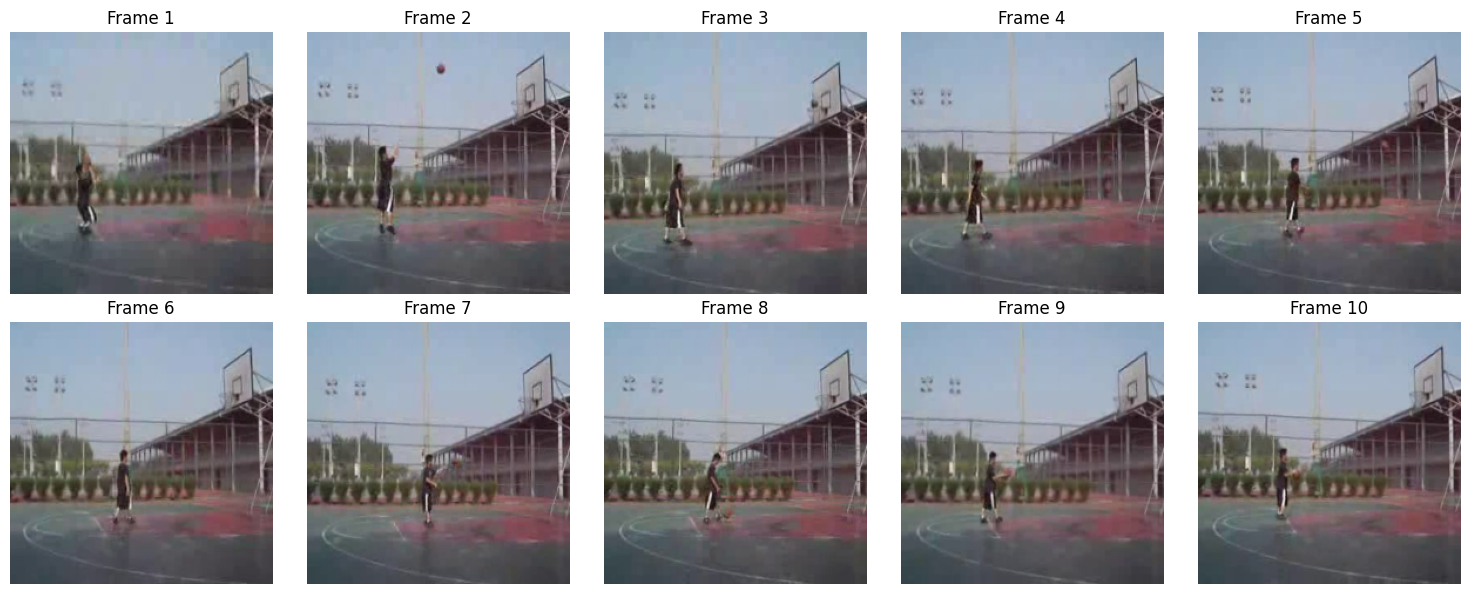

In [69]:
sample_frames = extract_frames(video_files[0])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_frames[i])
    ax.set_title(f"Frame {i+1}")
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "Figures/Plot_7_Video_Sample_Frames.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [70]:
Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
    X_video, y_video,
    test_size=0.30,
    random_state=42,
    stratify=y_video
)

Xv_val, Xv_test, yv_val, yv_test = train_test_split(
    Xv_temp, yv_temp,
    test_size=0.50,
    random_state=42,
    stratify=yv_temp
)

print(Xv_train.shape, Xv_val.shape, Xv_test.shape)

(42, 10, 1280) (9, 10, 1280) (9, 10, 1280)


In [71]:
video_model = Sequential([
    Input(shape=(10, 1280)),
    LSTM(32),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

video_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

video_model.summary()

start_time = time.time()

video_history = video_model.fit(
    Xv_train,
    yv_train,
    validation_data=(Xv_val, yv_val),
    epochs=20,
    batch_size=8,
    verbose=1
)

video_training_time = time.time() - start_time

print(f"Training time: {video_training_time:.2f} seconds")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,219 (661.01 KB)

 Trainable params: 169,219 (661.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.3810 - loss: 1.1212 - val_accuracy: 0.6667 - val_loss: 0.9994
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8810 - loss: 0.8090 - val_accuracy: 0.8889 - val_loss: 0.7788
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9762 - loss: 0.5479 - val_accuracy: 0.8889 - val_loss: 0.6659
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.3787 - val_accuracy: 1.0000 - val_loss: 0.3602
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.2630 - val_accuracy: 0.8889 - val_loss: 0.4243
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.1902 - val_accuracy: 1.0000 - val_loss: 0.3318
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.1457 - val_accuracy: 1.0000 - val_loss: 0.2644
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.1100 - val_accuracy: 1.0000 - val_loss: 0.2131

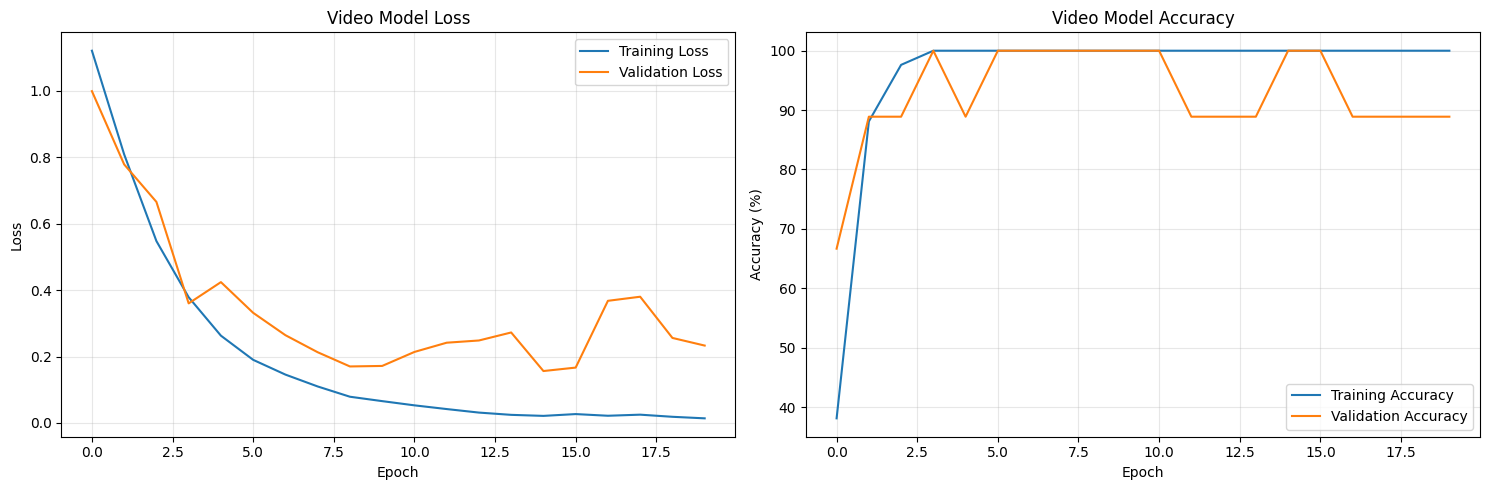

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(video_history.history["loss"], label="Training Loss")
axes[0].plot(video_history.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Video Model Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    np.array(video_history.history["accuracy"]) * 100,
    label="Training Accuracy"
)
axes[1].plot(
    np.array(video_history.history["val_accuracy"]) * 100,
    label="Validation Accuracy"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Video Model Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figures/Plot_8_Video_Training_Validation_Curves.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

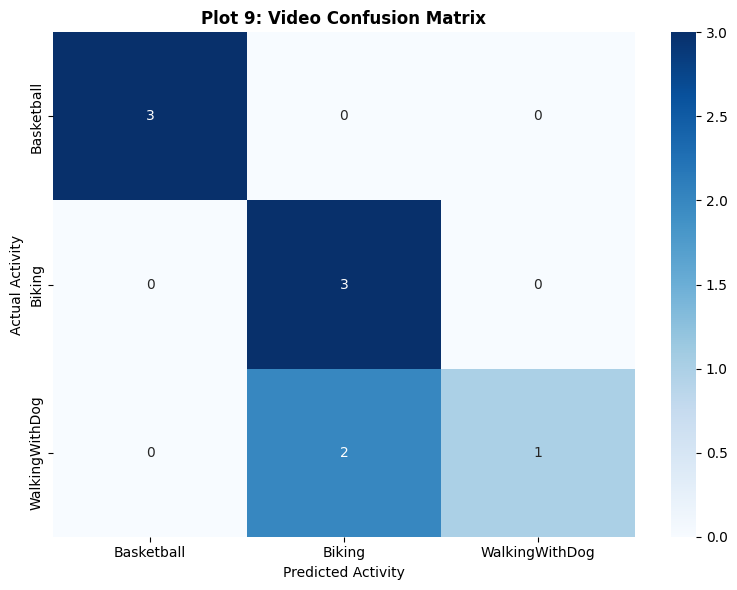

Video Accuracy: 77.78%
Video Macro F1: 75.00%


In [73]:
video_prob = video_model.predict(Xv_test, verbose=0)
video_pred = np.argmax(video_prob, axis=1)

video_accuracy = accuracy_score(yv_test, video_pred)
video_f1 = f1_score(yv_test, video_pred, average="macro")

cm_video = confusion_matrix(yv_test, video_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_video,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=selected_classes,
    yticklabels=selected_classes
)

plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.title("Plot 9: Video Confusion Matrix", fontweight="bold")

plt.tight_layout()

plt.savefig(
    "Figures/Plot_9_Video_Confusion_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(f"Video Accuracy: {video_accuracy * 100:.2f}%")
print(f"Video Macro F1: {video_f1 * 100:.2f}%")

In [74]:
i = 0

predicted_class = selected_classes[video_pred[i]]
actual_class = selected_classes[yv_test[i]]
confidence = video_prob[i][video_pred[i]]

print("Predicted class :", predicted_class)
print("Actual class    :", actual_class)
print(f"Confidence      : {confidence:.4f}")

Predicted class : Biking
Actual class    : Biking
Confidence      : 0.9885


In [76]:
np.random.seed(42)

VOCAB_SIZE = 10
SEQ_LEN = 5
SOS = VOCAB_SIZE + 1

N = 6000

seq2seq_data = np.random.randint(
    1,
    VOCAB_SIZE + 1,
    size=(N, SEQ_LEN)
)

seq2seq_target = np.flip(
    seq2seq_data,
    axis=1
)

decoder_input = np.zeros_like(seq2seq_target)
decoder_input[:, 0] = SOS
decoder_input[:, 1:] = seq2seq_target[:, :-1]

print("Encoder input:", seq2seq_data.shape)
print("Decoder input:", decoder_input.shape)
print("Target:", seq2seq_target.shape)

Encoder input: (6000, 5)
Decoder input: (6000, 5)
Target: (6000, 5)


In [77]:
X_seq_train, X_seq_temp, D_seq_train, D_seq_temp, y_seq_train, y_seq_temp = train_test_split(
    seq2seq_data,
    decoder_input,
    seq2seq_target,
    test_size=0.20,
    random_state=42
)

X_seq_val, X_seq_test, D_seq_val, D_seq_test, y_seq_val, y_seq_test = train_test_split(
    X_seq_temp,
    D_seq_temp,
    y_seq_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_seq_train.shape)
print("Validation:", X_seq_val.shape)
print("Test:", X_seq_test.shape)

Train: (4800, 5)
Validation: (600, 5)
Test: (600, 5)


In [80]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Model

embedding_dim = 64
latent_dim = 128

encoder_inputs = Input(shape=(SEQ_LEN,))
encoder_embedding = Embedding(
    input_dim=VOCAB_SIZE + 2,
    output_dim=embedding_dim
)(encoder_inputs)

encoder_lstm = LSTM(
    latent_dim,
    return_state=True
)

_, state_h, state_c = encoder_lstm(encoder_embedding)

decoder_inputs = Input(shape=(SEQ_LEN,))

decoder_embedding = Embedding(
    input_dim=VOCAB_SIZE + 2,
    output_dim=embedding_dim
)(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=[state_h, state_c]
)

decoder_dense = Dense(
    VOCAB_SIZE + 2,
    activation="softmax"
)

decoder_outputs = decoder_dense(decoder_outputs)

seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

seq2seq_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 5, 64)     │        768 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 5, 64)     │        768 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 128),     │     98,816 │ embedding_2[0][0] │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 5, 128),  │     98,816 │ embedding_3[0][0… │
│                     │ (None, 128),      │            │ lstm_4[0][1],     │
│                     │ (None, 128)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 5, 12)     │      1,548 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 200,716 (784.05 KB)

 Trainable params: 200,716 (784.05 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
seq2seq_history = seq2seq_model.fit(
    [X_seq_train, D_seq_train],
    y_seq_train,
    validation_data=(
        [X_seq_val, D_seq_val],
        y_seq_val
    ),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.2887 - loss: 2.0091 - val_accuracy: 0.4057 - val_loss: 1.4738
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6852 - loss: 0.8960 - val_accuracy: 0.9477 - val_loss: 0.3717
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9747 - loss: 0.2229 - val_accuracy: 0.9860 - val_loss: 0.1361
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9951 - loss: 0.0934 - val_accuracy: 0.9977 - val_loss: 0.0642
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9978 - loss: 0.0544 - val_accuracy: 0.9977 - val_loss: 0.0506
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9992 - loss: 0.0342 - val_accuracy: 0.9997 - val_loss: 0.0284
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9998 - loss: 0.0227 - val_accuracy: 1.0000 - val_loss: 0.0184
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0166 - val_accuracy: 1.0000 - val_lo

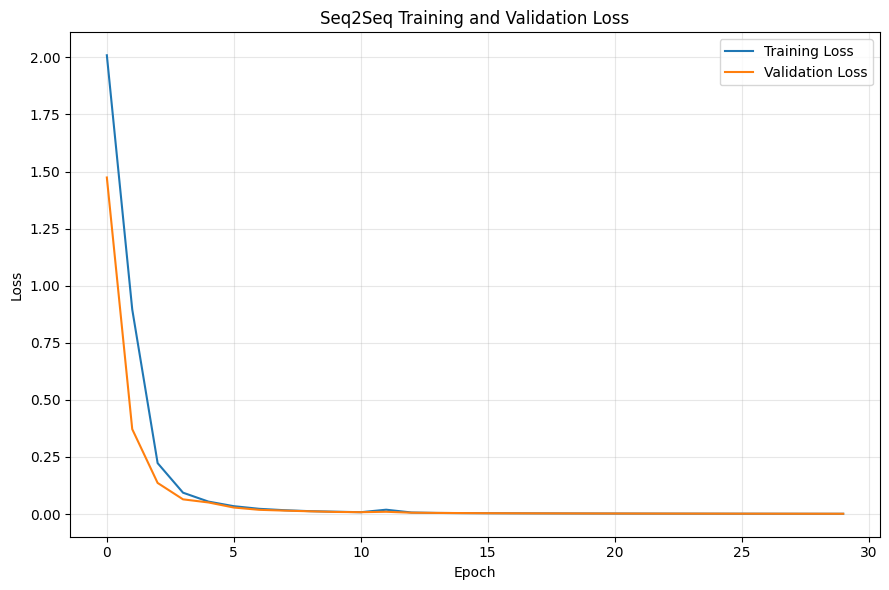

In [82]:
plt.figure(figsize=(9, 6))

plt.plot(
    seq2seq_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    seq2seq_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figures/Seq2Seq_Loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [83]:
encoder_model = Model(
    encoder_inputs,
    [state_h, state_c]
)

decoder_state_h = Input(shape=(latent_dim,))
decoder_state_c = Input(shape=(latent_dim,))
decoder_token = Input(shape=(1,))

decoder_emb = seq2seq_model.layers[3](decoder_token)

decoder_out, new_h, new_c = decoder_lstm(
    decoder_emb,
    initial_state=[decoder_state_h, decoder_state_c]
)

decoder_out = decoder_dense(decoder_out)

decoder_model = Model(
    [decoder_token, decoder_state_h, decoder_state_c],
    [decoder_out, new_h, new_c]
)

In [84]:
def decode_sequence(input_sequence):
    h, c = encoder_model.predict(
        input_sequence.reshape(1, SEQ_LEN),
        verbose=0
    )

    token = np.array([[SOS]])
    output_sequence = []

    for _ in range(SEQ_LEN):
        output, h, c = decoder_model.predict(
            [token, h, c],
            verbose=0
        )

        next_token = np.argmax(output[0, 0])

        output_sequence.append(next_token)
        token = np.array([[next_token]])

    return output_sequence

In [85]:
predicted_sequences = np.array([
    decode_sequence(x)
    for x in X_seq_test
])

token_accuracy = np.mean(
    predicted_sequences == y_seq_test
)

sequence_accuracy = np.mean(
    np.all(
        predicted_sequences == y_seq_test,
        axis=1
    )
)

print(f"Token Accuracy    : {token_accuracy * 100:.2f}%")
print(f"Sequence Accuracy : {sequence_accuracy * 100:.2f}%")

Token Accuracy    : 100.00%
Sequence Accuracy : 100.00%


In [86]:
print("Sample Input".ljust(25), "Actual Output".ljust(25), "Predicted Output")

for i in range(5):
    print(
        str(X_seq_test[i]).ljust(25),
        str(y_seq_test[i]).ljust(25),
        str(predicted_sequences[i])
    )

Sample Input              Actual Output             Predicted Output
[8 4 7 3 9]               [9 3 7 4 8]               [9 3 7 4 8]
[10  5 10  4  1]          [ 1  4 10  5 10]          [ 1  4 10  5 10]
[10  3  6  8  9]          [ 9  8  6  3 10]          [ 9  8  6  3 10]
[6 1 3 7 8]               [8 7 3 1 6]               [8 7 3 1 6]
[9 4 6 2 4]               [4 2 6 4 9]               [4 2 6 4 9]


In [87]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

video_precision = precision_score(
    yv_test, video_pred, average="macro", zero_division=0
)

video_recall = recall_score(
    yv_test, video_pred, average="macro", zero_division=0
)

consolidated_df = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU", "CNN-LSTM/GRU"],
    "Accuracy (%)": [
        rnn_accuracy * 100,
        lstm_accuracy * 100,
        gru_accuracy * 100,
        video_accuracy * 100
    ],
    "Precision (%)": [
        rnn_precision * 100,
        lstm_precision * 100,
        gru_precision * 100,
        video_precision * 100
    ],
    "Recall (%)": [
        rnn_recall * 100,
        lstm_recall * 100,
        gru_recall * 100,
        video_recall * 100
    ],
    "F1 (%)": [
        rnn_f1 * 100,
        lstm_f1 * 100,
        gru_f1 * 100,
        video_f1 * 100
    ],
    "Parameters": [
        rnn_parameters,
        lstm_parameters,
        gru_parameters,
        video_model.count_params()
    ]
})

consolidated_df

,Model,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
0,RNN,74.312861,74.183489,73.642423,73.785377,1974
1,LSTM,90.363081,90.512197,90.610014,90.449565,6006
2,GRU,90.261283,90.405216,90.415605,90.364122,4758
3,CNN-LSTM/GRU,77.777778,86.666667,77.777778,75.000000,169219
